In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [8]:
#check data set
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
#check missing value
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [10]:
#remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates removed")

Duplicates removed


In [11]:
#create column
df['Date'] = pd.to_datetime(
    df[['Year', 'Month']].assign(DAY=1)
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [12]:
#sort
df = df.sort_values('Date')

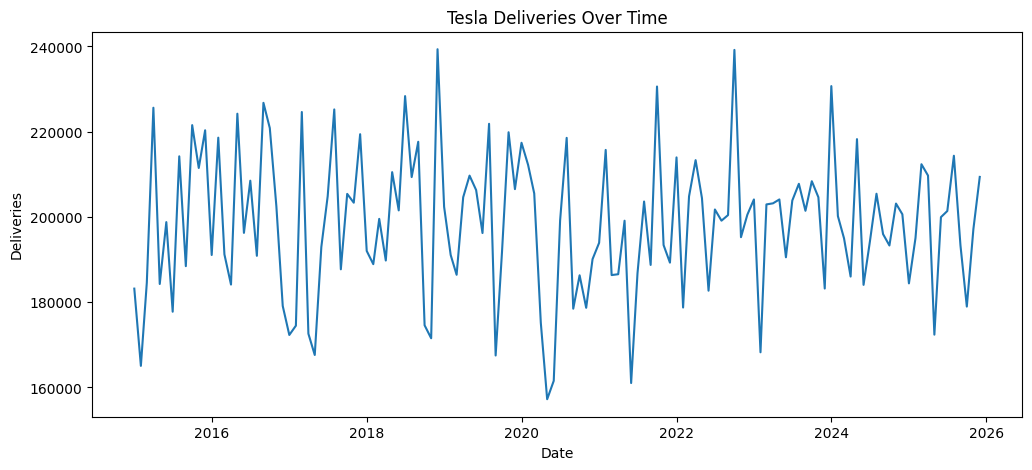

In [14]:
#data analysis
monthly_sales = (
    df.groupby('Date')['Estimated_Deliveries']
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(monthly_sales)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

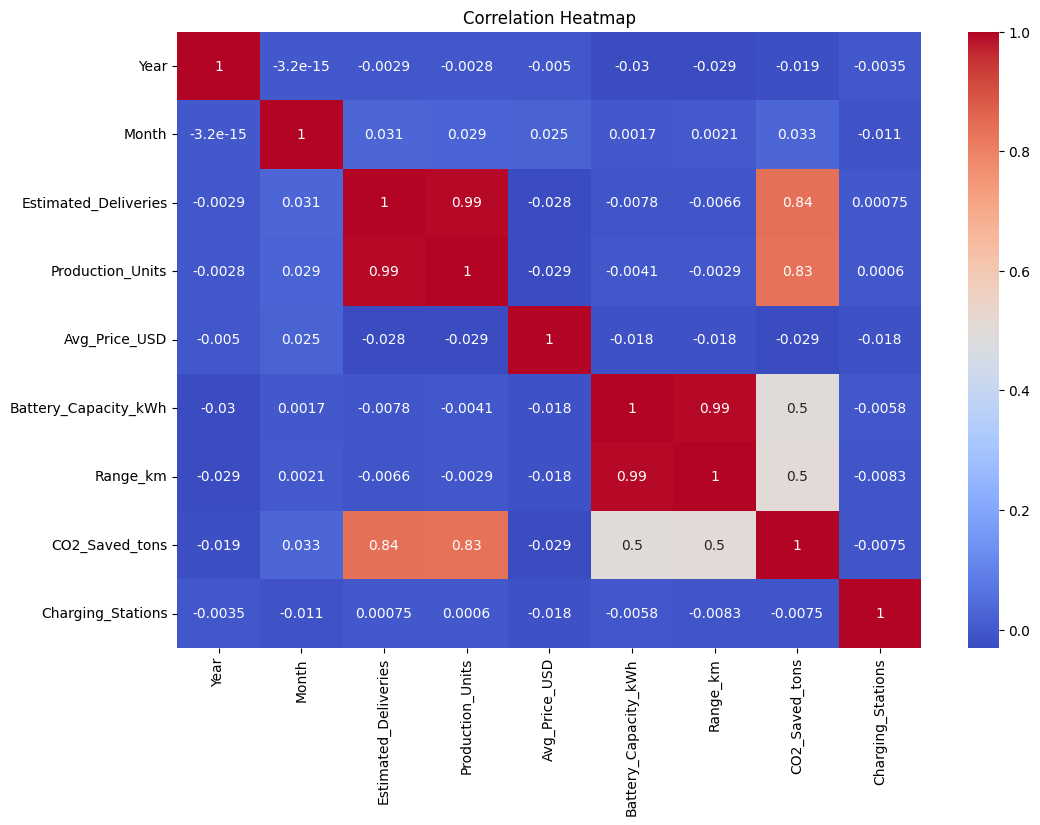

In [15]:
#heatmap
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

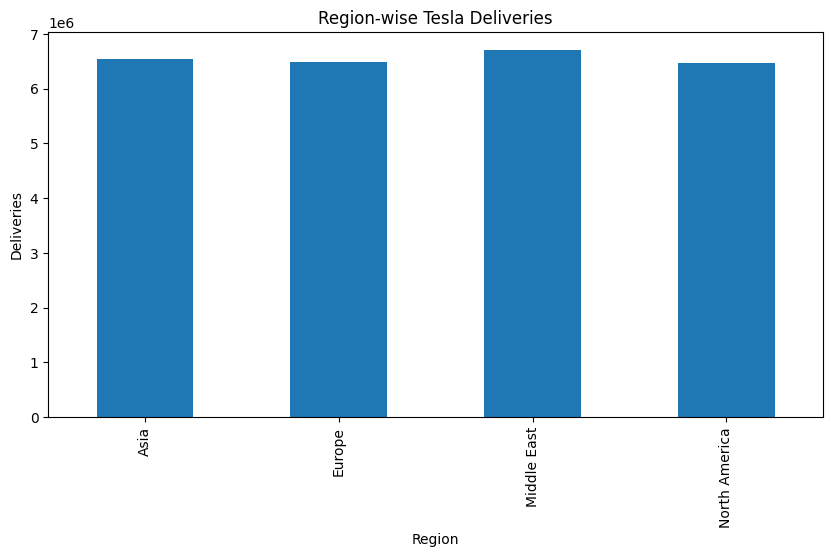

In [16]:
#regionwise
region_sales = (
    df.groupby('Region')['Estimated_Deliveries']
    .sum()
)

plt.figure(figsize=(10,5))

region_sales.plot(kind='bar')

plt.title("Region-wise Tesla Deliveries")
plt.ylabel("Deliveries")

plt.show()

In [21]:
#feature
df['Quarter'] = df['Date'].dt.quarter
df['Month_Num'] = df['Date'].dt.month
df['Lag_1'] = (
    df['Estimated_Deliveries']
    .shift(1)
)
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)
df.dropna(inplace=True)

In [22]:
#encode
df = pd.get_dummies(
    df,
    columns=['Region', 'Model', 'Source_Type'],
    drop_first=True
)

In [23]:
#define
y = df['Estimated_Deliveries']
X = df.drop(
    ['Estimated_Deliveries', 'Date'],
    axis=1
)

In [24]:
#tain&split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
#random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [26]:
predictions = rf.predict(X_test)

In [28]:
#evaluate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("R2 Score:", r2_score(y_test, predictions))

print("MAE:", mean_absolute_error(y_test, predictions))

print(
    "RMSE:",
    mean_squared_error(y_test, predictions)**0.5
)

R2 Score: 0.9862799958084865
MAE: 328.41507575757583
RMSE: 476.1915386974902


In [29]:
#importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

              Feature  Importance
2    Production_Units    0.990340
6      CO2_Saved_tons    0.001943
5            Range_km    0.001163
3       Avg_Price_USD    0.001117
11     Rolling_Mean_3    0.000978
7   Charging_Stations    0.000972
10              Lag_1    0.000959
0                Year    0.000645
1               Month    0.000312
9           Month_Num    0.000306


In [35]:
#hyperparameter tunning
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


In [32]:
#TimeSeries Forecasting
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly_sales,
    order=(1,1,1)
)

result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [33]:
forecast = result.forecast(steps=12)

print(forecast)

2026-01-01    201130.711312
2026-02-01    199815.368230
2026-03-01    199605.917024
2026-04-01    199572.564655
2026-05-01    199567.253726
2026-06-01    199566.408030
2026-07-01    199566.273364
2026-08-01    199566.251920
2026-09-01    199566.248506
2026-10-01    199566.247962
2026-11-01    199566.247875
2026-12-01    199566.247862
Freq: MS, Name: predicted_mean, dtype: float64


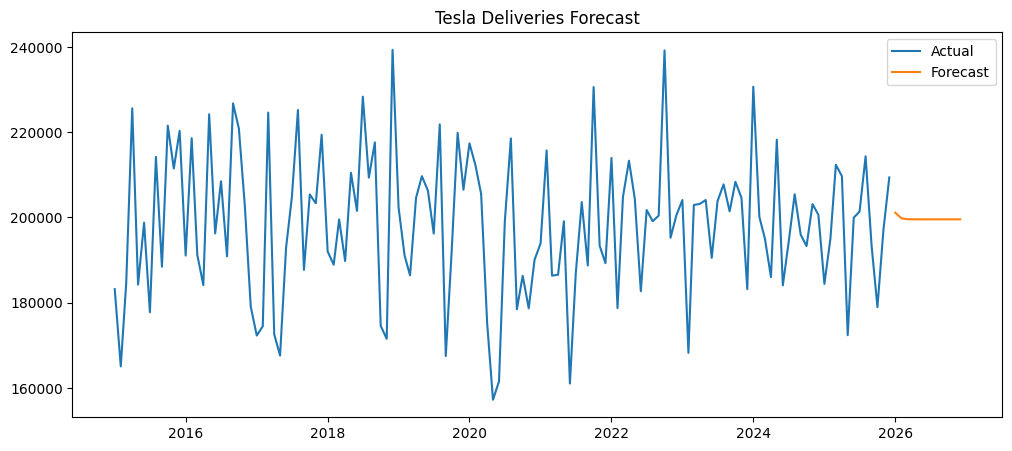

In [34]:
#forecast plot
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales,
    label='Actual'
)

plt.plot(
    forecast,
    label='Forecast'
)

plt.title("Tesla Deliveries Forecast")

plt.legend()

plt.show()